# Battery State-of-Health (SOH) Forecasting

Lithium-ion cells lose capacity as they age. Being able to **forecast** that decline is central to battery
management: it tells us how much usable life is left and when a cell will reach the end of its life.

Here the problem is posed as **time-series forecasting** — given the recent history of a cell's health,
predict how that health evolves over the next cycles.

We define **State of Health** as `SOH = QD / 1.1`: discharge capacity normalised by the nominal capacity
(1.1 Ah). A cell is treated as **end-of-life (EOL)** once SOH falls to **0.8** (80%).

**Task.** From a window of the most recent `L` cycles of SOH, forecast SOH for the next `H` cycles.

The notebook builds up from simple model-free baselines to an LSTM encoder–decoder, and then tests how far
ahead the forecast stays reliable.

> The LSTM uses TensorFlow and runs best on a GPU. The scikit-learn baselines run on CPU anywhere.

## 0. Setup

In [34]:
import os, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED=42; np.random.seed(SEED)
NOMINAL, EOL = 1.1, 0.8
L, STRIDE = 30, 10          # observed window length, sliding stride

def find_csv(pat):
    for base in ["/kaggle/input","dataset","."]:
        h=glob.glob(os.path.join(base,"**",pat),recursive=True)
        if h: return h[0]
    raise FileNotFoundError(pat)

# FULL trajectory file (not the 100-cycle subset) — we need the whole degradation curve.
CSV=find_csv("Lithium-Ion Battery Cycle Life.csv")
print("Using:",CSV)
df=pd.read_csv(CSV)
print("rows",df.shape,"cells",df.battery_id.nunique())

Using: /kaggle/input/datasets/solitaryseeker/lithium-ion-battery-cycle-life-time-series-dataset/Lithium-Ion Battery Cycle Life.csv
rows (114738, 13) cells 140


## 1. Building the SOH curves

For each cell we drop initialisation and dead rows (`QD <= 0.5`), remove duplicate cycle numbers, and smooth
the capacity signal with a centred rolling median (raw capacity readings are noisy). The result is one clean
SOH-vs-cycle curve per cell.

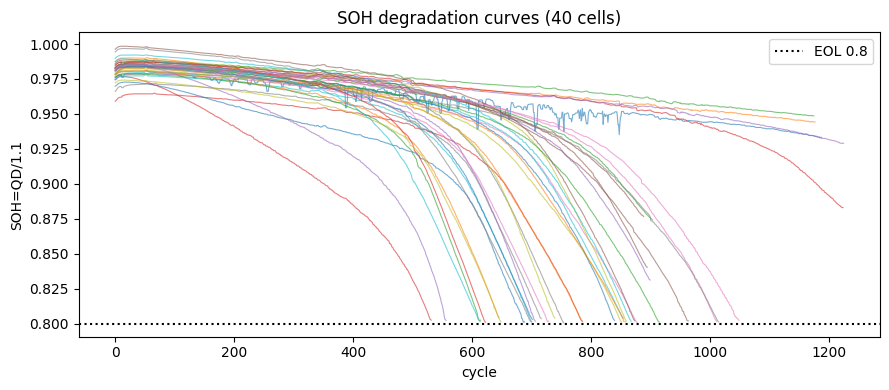

In [35]:
df=df[df["QD"]>0.5].sort_values(["battery_id","cycle"])
def soh_curve(g):
    g=g.drop_duplicates("cycle").sort_values("cycle")
    return (g["QD"]/NOMINAL).rolling(5,min_periods=1,center=True).median().values
curves={b:soh_curve(g) for b,g in df.groupby("battery_id")}

fig,ax=plt.subplots(figsize=(9,4))
for s in list(curves.values())[:40]:
    ax.plot(s,lw=.8,alpha=.6)
ax.axhline(EOL,color="k",ls=":",label="EOL 0.8")
ax.set(title="SOH degradation curves (40 cells)",xlabel="cycle",ylabel="SOH=QD/1.1"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Turning curves into a forecasting dataset

We slide a window along each curve: the input is `L` past SOH values, the target is the next `H` values.
The train/test split is **done by cell**, so no cell appears in both — the model is always forecasting
trajectories it has never seen.

In [36]:
cells=sorted(c for c in curves if len(curves[c])>=L+50)
rng=np.random.RandomState(SEED); rng.shuffle(cells)
n_te=int(0.2*len(cells)); test_cells=cells[:n_te]; train_cells=cells[n_te:]
print(f"cells: {len(cells)} | train {len(train_cells)} | test {len(test_cells)}")

def windows(cell_set,H):
    X,Y=[],[]
    for b in cell_set:
        s=curves[b]
        for t in range(0,len(s)-L-H+1,STRIDE):
            X.append(s[t:t+L]); Y.append(s[t+L:t+L+H])
    return np.array(X),np.array(Y)

def fit_predict_delta(model,Xtr,Ytr,Xte):
    """Train and predict in DELTA space: subtract the last observed SOH from the
    window and the target, standardise X and Y, predict the change, add it back.
    This is what lets neural models compete on a narrow-band signal like SOH."""
    ltr,lte=Xtr[:,-1:],Xte[:,-1:]
    Xtr_d,Ytr_d,Xte_d=Xtr-ltr,Ytr-ltr,Xte-lte
    sx,sy=StandardScaler().fit(Xtr_d),StandardScaler().fit(Ytr_d)
    model.fit(sx.transform(Xtr_d),sy.transform(Ytr_d))
    return sy.inverse_transform(model.predict(sx.transform(Xte_d)))+lte

cells: 140 | train 112 | test 28


## 3. Models, delta-modelling, and how error grows with the horizon

Capacity fades within a narrow band (SOH ≈ 0.80–0.97), so predicting the **absolute** level is an awkward target:
a model can look good simply by guessing a near-constant value. We therefore train every learned model in
**delta space** — subtract the last observed SOH from both the input window and the target, standardise, predict
the *change* from where the cell currently is, then add that change back. This single step sharply improves the
learned models (and is what lets the neural network compete at all).

Two model-free baselines vs three learned regressors, at horizons of **H = 10 / 20 / 50 cycles**:

- **Persistence** — repeat the last observed SOH (the classic naive forecast).
- **Linear extrapolation** — fit a line to the window and extend it forward.
- **Ridge / RandomForest / MLP** — multi-output regressors trained in delta space.

Metric: RMSE on SOH (shown ×10⁻² for readability); lower is better.

In [37]:
def lin_extrap(X,H):
    t=np.arange(L)
    return np.array([np.polyval(np.polyfit(t,r,1), L+np.arange(H)) for r in X])

def make_models():
    return {"Ridge":MultiOutputRegressor(Ridge()),
            "RandomForest":RandomForestRegressor(n_estimators=200,random_state=SEED,n_jobs=-1),
            "MLP":MLPRegressor(hidden_layer_sizes=(128,64),max_iter=2000,
                               early_stopping=True,n_iter_no_change=30,random_state=SEED)}

rows=[]
for H in [10,20,50,100]:
    Xtr,Ytr=windows(train_cells,H); Xte,Yte=windows(test_cells,H)
    rmse=lambda P: np.sqrt(mean_squared_error(Yte,P))*100
    rec={"H":H,
         "Persistence":rmse(np.repeat(Xte[:,-1:],H,axis=1)),   # model-free baselines
         "Linear":rmse(lin_extrap(Xte,H))}
    for k,m in make_models().items():                          # learned models, delta space
        rec[k]=rmse(fit_predict_delta(m,Xtr,Ytr,Xte))
    rows.append(rec); print(rec)
res=pd.DataFrame(rows).set_index("H").round(3); res

{'H': 10, 'Persistence': np.float64(0.23700443993993148), 'Linear': np.float64(0.06785131655552748), 'Ridge': np.float64(0.04620832819162734), 'RandomForest': np.float64(0.03791151831014638), 'MLP': np.float64(0.03636495755483192)}
{'H': 20, 'Persistence': np.float64(0.43981142359960446), 'Linear': np.float64(0.11015886868127146), 'Ridge': np.float64(0.07190873981870209), 'RandomForest': np.float64(0.05955674894652239), 'MLP': np.float64(0.05566818549206464)}
{'H': 50, 'Persistence': np.float64(0.955889469522493), 'Linear': np.float64(0.29502489297675955), 'Ridge': np.float64(0.17833883488543725), 'RandomForest': np.float64(0.14478105914555228), 'MLP': np.float64(0.14137326974302283)}
{'H': 100, 'Persistence': np.float64(1.5333599622394722), 'Linear': np.float64(0.6561449183961956), 'Ridge': np.float64(0.38824263115707885), 'RandomForest': np.float64(0.346183932627289), 'MLP': np.float64(0.3544860946455797)}


,Persistence,Linear,Ridge,RandomForest,MLP
H,,,,,
10,0.237,0.068,0.046,0.038,0.036
20,0.440,0.110,0.072,0.060,0.056
50,0.956,0.295,0.178,0.145,0.141
100,1.533,0.656,0.388,0.346,0.354


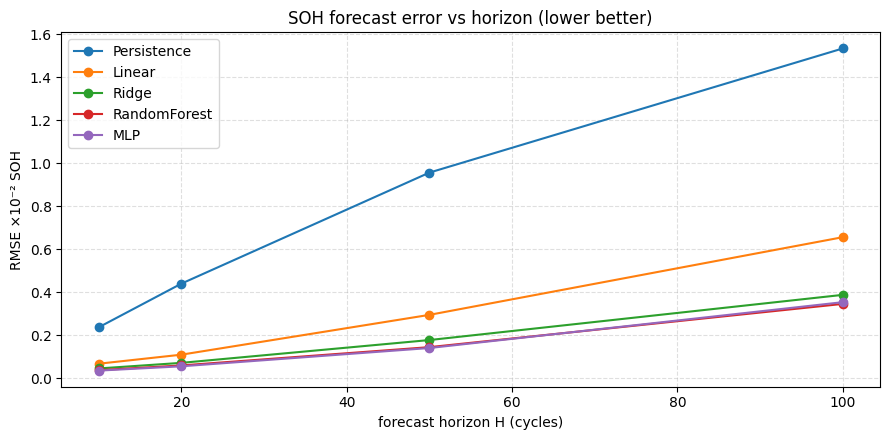

In [38]:
res.plot(marker="o",figsize=(9,4.5))
plt.title("SOH forecast error vs horizon (lower better)")
plt.ylabel("RMSE ×10⁻² SOH"); plt.xlabel("forecast horizon H (cycles)")
plt.grid(ls="--",alpha=.4); plt.tight_layout(); plt.show()

## 4. Sequence models — LSTM and Transformer

Two sequence models, both trained in the same **delta space** as the regressors above (a plain network on
absolute SOH collapses to a near-constant prediction). The **LSTM encoder–decoder** compresses the window and
unrolls the H-step forecast; the **Transformer** replaces recurrence with **self-attention** over the window.
Both are skipped automatically if TensorFlow is unavailable.

In [39]:
H=20
Xtr,Ytr=windows(train_cells,H); Xte,Yte=windows(test_cells,H)
# same delta space as the regressors: subtract last observed value, then standardise
ltr,lte=Xtr[:,-1:],Xte[:,-1:]
Xtr_d,Ytr_d,Xte_d=Xtr-ltr,Ytr-ltr,Xte-lte
mx,sdx=Xtr_d.mean(),Xtr_d.std(); my,sdy=Ytr_d.mean(),Ytr_d.std()
Xtr_n=(Xtr_d-mx)/sdx; Ytr_n=(Ytr_d-my)/sdy; Xte_n=(Xte_d-mx)/sdx
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Sequential
    model=Sequential([
        layers.Input((L,1)),
        layers.LSTM(64),                          # encoder
        layers.RepeatVector(H),
        layers.LSTM(64,return_sequences=True),    # decoder
        layers.TimeDistributed(layers.Dense(1)),
        layers.Reshape((H,)),
    ])
    model.compile("adam","mse")
    model.fit(Xtr_n[...,None],Ytr_n,validation_split=0.1,epochs=100,batch_size=128,verbose=0)
    P=model.predict(Xte_n[...,None],verbose=0)*sdy+my+lte    # un-standardise, add last value back
    print(f"LSTM seq2seq (delta) @H{H}: RMSE={np.sqrt(mean_squared_error(Yte,P))*100:.3f} x1e-2 SOH")
except Exception as e:
    print("TensorFlow unavailable -> skipping LSTM (use sklearn baselines):",e)

LSTM seq2seq (delta) @H20: RMSE=0.057 x1e-2 SOH


In [40]:
# Transformer encoder (self-attention) — same delta space as the LSTM
H=20
Xtr,Ytr=windows(train_cells,H); Xte,Yte=windows(test_cells,H)
ltr,lte=Xtr[:,-1:],Xte[:,-1:]
Xtr_d,Ytr_d,Xte_d=Xtr-ltr,Ytr-ltr,Xte-lte
mx,sdx=Xtr_d.mean(),Xtr_d.std(); my,sdy=Ytr_d.mean(),Ytr_d.std()
Xtr_n=(Xtr_d-mx)/sdx; Ytr_n=(Ytr_d-my)/sdy; Xte_n=(Xte_d-mx)/sdx
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    d_model,heads,ff=32,4,64
    inp=layers.Input((L,1))
    x=layers.Dense(d_model)(inp)
    x=x+layers.Embedding(L,d_model)(tf.range(L))           # learned positional encoding
    a=layers.MultiHeadAttention(num_heads=heads,key_dim=d_model)(x,x)
    x=layers.LayerNormalization()(x+a)                     # attention + residual
    f=layers.Dense(ff,activation="relu")(x); f=layers.Dense(d_model)(f)
    x=layers.LayerNormalization()(x+f)                     # feed-forward + residual
    x=layers.GlobalAveragePooling1D()(x)
    out=layers.Dense(H)(x)
    tfm=Model(inp,out); tfm.compile("adam","mse")
    tfm.fit(Xtr_n[...,None],Ytr_n,validation_split=0.1,epochs=100,batch_size=128,verbose=0)
    P=tfm.predict(Xte_n[...,None],verbose=0)*sdy+my+lte
    print(f"Transformer (delta) @H{H}: RMSE={np.sqrt(mean_squared_error(Yte,P))*100:.3f} x1e-2 SOH")
except Exception as e:
    print("TensorFlow unavailable -> skipping Transformer:",e)

I0000 00:00:1781411012.140149     175 service.cc:152] XLA service 0x7c462c292020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781411012.140195     175 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781411012.140199     175 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781411015.375512     175 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Transformer (delta) @H20: RMSE=0.066 x1e-2 SOH


## 5. Do extra channels (internal resistance, temperature) help?

So far the forecast uses only the SOH history. The dataset also logs **internal resistance (IR)** and
**temperature** every cycle — quantities tied to the physics of degradation. Here we rebuild the windows with
these as extra input channels (SOH + IR + temperature) and compare against SOH-only, keeping the delta-modelling
and everything else identical.

In [41]:
def smooth(s): return pd.Series(s).rolling(5,min_periods=1,center=True).median().values
mc={}
for b,g in df.groupby("battery_id"):
    g=g.drop_duplicates("cycle").sort_values("cycle")
    mc[b]={"SOH":smooth(g["QD"].values/NOMINAL),"IR":smooth(g["IR"].values),"T":smooth(g["Tavg"].values)}

def win_mc(cell_set,H,chans):
    X,Y=[],[]
    for b in cell_set:
        d=mc[b]; n=len(d["SOH"])
        for t in range(0,n-L-H+1,STRIDE):
            X.append(np.stack([d[c][t:t+L] for c in chans],axis=-1))   # (L, n_channels)
            Y.append(d["SOH"][t+L:t+L+H])
    return np.array(X),np.array(Y)

def fit_pred_mc(model,Xtr,Ytr,Xte):
    # per-channel delta + standardise; target = SOH delta (same recipe as section 3)
    lS_tr,lS_te=Xtr[:,-1:,0],Xte[:,-1:,0]
    Xtr_d=(Xtr-Xtr[:,-1:,:]).reshape(len(Xtr),-1)
    Xte_d=(Xte-Xte[:,-1:,:]).reshape(len(Xte),-1)
    Ytr_d=Ytr-lS_tr
    sx,sy=StandardScaler().fit(Xtr_d),StandardScaler().fit(Ytr_d)
    model.fit(sx.transform(Xtr_d),sy.transform(Ytr_d))
    return sy.inverse_transform(model.predict(sx.transform(Xte_d)))+lS_te

rows=[]
for chans,tag in [(["SOH"],"SOH only"),(["SOH","IR","T"],"SOH+IR+Temp")]:
    for H in [10,20,50]:
        Xtr,Ytr=win_mc(train_cells,H,chans); Xte,Yte=win_mc(test_cells,H,chans)
        for mname,m in {"RF":RandomForestRegressor(n_estimators=200,random_state=SEED,n_jobs=-1),
                        "MLP":MLPRegressor(hidden_layer_sizes=(128,64),max_iter=2000,
                                           early_stopping=True,n_iter_no_change=30,random_state=SEED)}.items():
            r=np.sqrt(mean_squared_error(Yte,fit_pred_mc(m,Xtr,Ytr,Xte)))*100
            rows.append({"model":mname,"input":tag,"H":H,"RMSE":round(r,3)})
mc_res=pd.DataFrame(rows).pivot_table(index=["model","H"],columns="input",values="RMSE")
mc_res["gain"]=(mc_res["SOH only"]-mc_res["SOH+IR+Temp"]).round(3)
print(mc_res)

input     SOH only  SOH+IR+Temp   gain
model H                               
MLP   10     0.036        0.041 -0.005
      20     0.056        0.058 -0.002
      50     0.141        0.138  0.003
RF    10     0.038        0.037  0.001
      20     0.060        0.059  0.001
      50     0.145        0.138  0.007


## 6. Forecasting the full curve — and the knee problem

By feeding the model its own predictions, we can roll the forecast forward from an early window and rebuild the
**entire** degradation curve. This is where the hard part shows up: capacity fade has a late **"knee"** — a
point where decline suddenly accelerates — that a short early window struggles to anticipate.

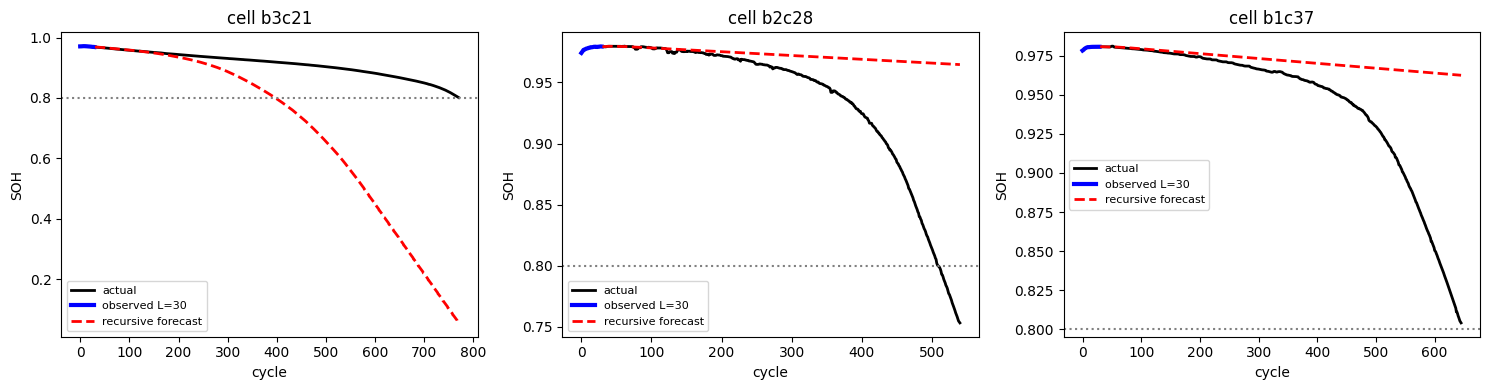

In [42]:
# RandomForest trained in delta space, reused for recursive roll-out
H=20
Xtr,Ytr=windows(train_cells,H); ltr=Xtr[:,-1:]
sx,sy=StandardScaler().fit(Xtr-ltr),StandardScaler().fit(Ytr-ltr)
rf=RandomForestRegressor(n_estimators=300,random_state=SEED,n_jobs=-1).fit(
    sx.transform(Xtr-ltr), sy.transform(Ytr-ltr))

def forecast_next(window):                 # window: last L SOH values -> next H
    last=window[-1]
    d=(np.array(window)-last).reshape(1,-1)
    return sy.inverse_transform(rf.predict(sx.transform(d)))[0]+last

fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,bid in zip(axes,test_cells[:3]):
    s=curves[bid]; hist=list(s[:L])
    while len(hist)<len(s):
        hist.extend(forecast_next(hist[-L:])[:STRIDE])
    hist=np.array(hist[:len(s)])
    ax.plot(s,"k-",lw=2,label="actual")
    ax.plot(np.arange(L),s[:L],"b-",lw=3,label=f"observed L={L}")
    ax.plot(np.arange(L,len(s)),hist[L:],"r--",lw=2,label="recursive forecast")
    ax.axhline(EOL,color="gray",ls=":")
    ax.set(title=f"cell {bid}",xlabel="cycle",ylabel="SOH"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Summary

- **Delta-modelling is what makes forecasting work here.** Because SOH lives in a narrow band, predicting the
  absolute level is a poor target; predicting the change from the last observed value (then adding it back)
  sharply improves every learned model and is what lets the neural networks match the tree/linear baselines.
- **Forecast error grows steadily with the horizon** (tested up to H=100). The naive baselines fall apart first;
  the learned models separate from them, but tree (RandomForest) and neural (MLP/LSTM/Transformer) models stay
  close to each other — the aggregate per-cycle signal does not give the sequence models a decisive edge.
- **Extra channels add little for short-horizon forecasting.** Internal resistance and temperature barely
  improve on SOH-only prediction (SOH is strongly self-predictive over a 30-cycle window); the small gains show
  up only at the longest horizons, consistent with IR being a slower degradation signal.
- **The knee is the real challenge.** Rolling a forecast forward from an early window captures the gentle early
  fade but tends to miss the late accelerated drop. Anticipating that knee is the open problem.
- **Where to go next:** forecast SOH and remaining-useful-life jointly (multitask, as in Pham et al. 2022); and
  push toward the in-cycle voltage/current/temperature signals — not in this aggregated CSV — that the strongest
  published models rely on.